# Локальные признаки в регрессии

Рассмотрим ещё одну идею для формирования признаков для последующего применения линейной регрессии. Идея состоит в формировании из вектора $x$ некоторого вектора $z$, такого, чтобы при построении регрессионной модели $y=zw$ изменение одного веса $w_i$ приводило к изменению не всей зависимости данных, а лишь к локальному изменению зависимости. К примеру, чтобы изменение веса $w_1$ приводило к изменению функции в окрестности $0$, а веса $w_3$ в окрестности $6$.

Для применения полиномиальных признаков или каких-либо других <b>глобальных признаков</b> требуется иметь представление о виде зависимости в данных. Локальные признаки не требуют особых предположений о данных. 

То есть мы бы хотели получить что-то такое:

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/YSR03KLP/rbf-example.png"/>

Поменялся один вес $w_1$ и функция поменяла свой вид лишь в окрестности точки 0.

Необходимо выбрать набор функций $(\varphi_1,\dots,\varphi_m)$, с помощью которых вектор $x$ преобразуется в вектор $z$, размерности $m$:

$$
\begin{pmatrix}
x_1
\\
\vdots
\\
x_n
\end{pmatrix}
\rightarrow
\begin{pmatrix}
\varphi_1(x_1,\dots,x_n)
\\
\vdots
\\
\varphi_m(x_1,\dots,x_n)
\end{pmatrix}$$

Единственное требование, что функции $\varphi$ должны иметь большое ненулевое значение в некоторой области и быстро приближаться к нулю вне этой области, это и есть **локальность**.

Рассмотрим применение радиальных базисных функций, а точнее гауссовских функций в качестве функций $\varphi$, который выглядят следующим образом:

$$\varphi(x; \mu)=e^{-\frac{1}{2s^2}||x-\mu||^2}$$

Для получения же базиса $\varphi_1,\dots,\varphi_m$ распределим центры $\mu_1,\dots,\mu_m$ равномерно на отрезке $[x_{min},x_{max}]$, на котором распределены данные. То есть $\mu_i=x_{min}+\frac{i-1}{m-1}(x_{max}-x_{min})$, далее базисные функции определяются как $\varphi_i(x)=\varphi(x;\mu_i)$.

Параметр $s$ имеет смысл выбирать пропорционально расстоянию между центрами соседних функций.

Для этого опишем класс-трансформер, который будет преобразовывать вектор $x$ в вектор $z$.

In [2]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RANSACRegressor, TheilSenRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import pandas as pd

In [3]:
# функция для генерации данных
def generate_samples(function, n_samples, x_min=0, x_max=10, sigma=1):
    x = np.random.uniform(x_min, x_max, n_samples)
    y = function(x) + np.random.normal(0, sigma, n_samples)
    return x, y

In [4]:
## Класс для преобразования данных в гауссовские признаки
class GaussianFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, N, width_factor=.5):
        self.N = N
        self.width_factor = width_factor
    
    @staticmethod
    def _gauss_basis(x, center, width, axis=None):
        arg = (x - center) / width
        return np.exp(-0.5 * np.sum(arg ** 2, axis))
        
    def fit(self, X, y=None):
        self.centers_ = np.linspace(X.min(), X.max(), self.N)
        self.width_ = self.width_factor * (self.centers_[1] - self.centers_[0])
        return self
        
    def transform(self, X):
        return self._gauss_basis(X[:, :, None], self.centers_, self.width_, axis=1)

Посмотрим эффект на малом числе точек. Мы видим довольно гладкое приближение 

Коэффициенты (веса гауссианов):
[15.73697722 17.98053944 15.46875841 21.99083225 23.12897179]


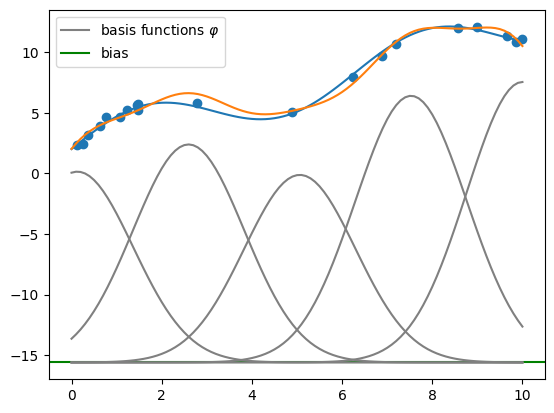

In [5]:
# Реальная зависимость в данных
relation = lambda x: 2 + x + 2 * np.sin(x) # использование numpy-функций позволяет использовать операции с массивами
# генерируем выборку
num_samples = 20    # Размер выборки
sigma = 0.3          # Дисперсия шума
x_min, x_max = 0, 10
x, center = generate_samples(relation, num_samples, x_min, x_max, sigma)

gf = GaussianFeatures(5)
lr = LinearRegression()
model = make_pipeline(gf, lr)

model.fit(x[:,None], center)

print("Коэффициенты (веса гауссианов):")
print(lr.coef_)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, center)
plt.plot(t, relation(t))

plt.plot(t, model.predict(t[:,None]))
plt.plot([0],[0], color="gray", label="basis functions $\\varphi$")
plt.axhline(lr.intercept_, color = "green", label="bias")
plt.plot(t, lr.intercept_ + gf.transform(t[:,None]) * lr.coef_, color="gray")
plt.legend()

Пример на большем участке данных:

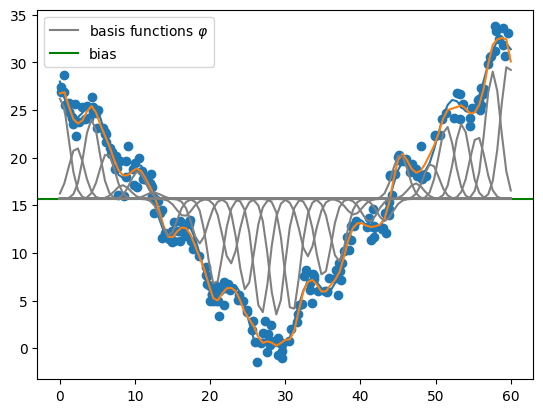

In [22]:
# Реальная зависимость в данных
relation = lambda x: np.abs(2 + x + 2 * np.sin(x) - 30) # использование numpy-функций позволяет использовать операции с массивами
# генерируем выборку
num_samples = 220    # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 60
x, center = generate_samples(relation, num_samples, x_min, x_max, sigma)

gf = GaussianFeatures(30)
lr = LinearRegression()
model = make_pipeline(gf, lr)

model.fit(x[:,None], center)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, center)
plt.plot(t, relation(t))

plt.plot(t, model.predict(t[:,None]))
plt.plot([0],[0], color="gray", label="basis functions $\\varphi$")
plt.axhline(lr.intercept_, color = "green", label="bias")
plt.plot(t, lr.intercept_ + gf.transform(t[:,None]) * lr.coef_, color="gray")
plt.legend()

А вот обучить полином на том же отрезке данных не удастся:

/home/ivanbalashov/LearningMachine/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.924489971518621e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


(1.5531543811231407, 42.16870042661221)

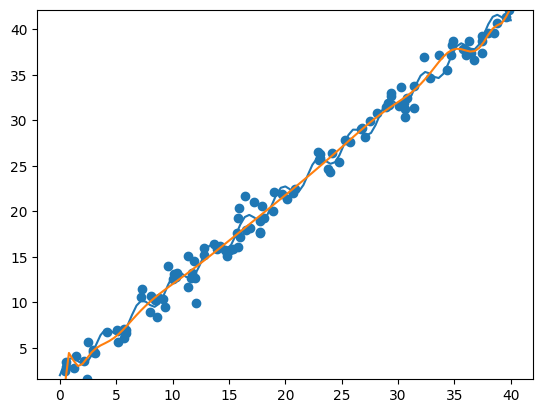

In [10]:
# Реальная зависимость в данных
relation = lambda x: 2 + x + 2 * np.sin(x) * np.cos(x) # использование numpy-функций позволяет использовать операции с массивами
# генерируем выборку
num_samples = 120    # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 40
x, center = generate_samples(relation, num_samples, x_min, x_max, sigma)

scaler = StandardScaler()
gf = PolynomialFeatures(degree=28)
lr = Ridge(alpha=0.1)
model = make_pipeline(scaler, gf, lr)

model.fit(x[:,None], center)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, center)
plt.plot(t, relation(t))

plt.plot(t, model.predict(t[:,None]))
plt.ylim(center.min(), center.max())

(2.1710866911144593, 24.115353081302203)

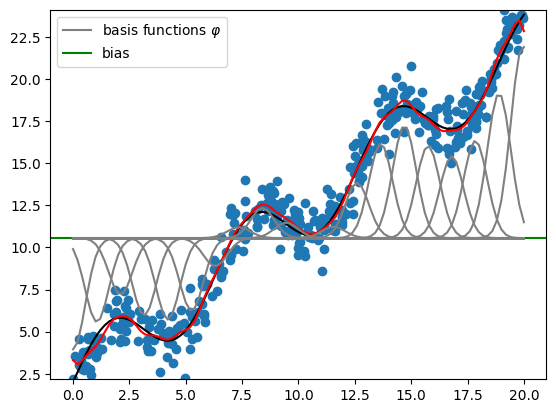

In [7]:
# Реальная зависимость в данных
relation = lambda x: 2 + x + 2 * np.sin(x) # использование numpy-функций позволяет использовать операции с массивами
# генерируем выборку
num_samples = 400    # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 20
x, center = generate_samples(relation, num_samples, x_min, x_max, sigma)

gf = GaussianFeatures(20,0.5)
lr = LinearRegression()
model = make_pipeline(gf, lr)

model.fit(x[:,None], center)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, center)
plt.plot(t, relation(t), color="black")

plt.plot(t, model.predict(t[:,None]),color="red")
plt.plot([0],[0], color="gray", label="basis functions $\\varphi$")
plt.axhline(lr.intercept_, color = "green", label="bias")
plt.plot(t, lr.intercept_ + gf.transform(t[:,None]) * lr.coef_, color="gray")
plt.legend()
plt.ylim(center.min(), center.max())

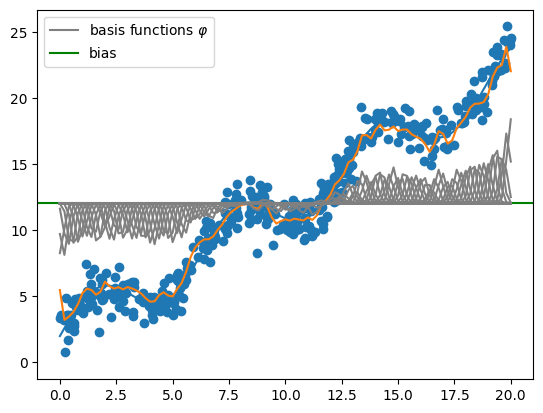

In [19]:
# Реальная зависимость в данных
relation = lambda x: 2 + x + 2 * np.sin(x) # использование numpy-функций позволяет использовать операции с массивами
# генерируем выборку
num_samples = 400    # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 20
x, center = generate_samples(relation, num_samples, x_min, x_max, sigma)

gf = GaussianFeatures(120,1)
lr = Ridge()
model = make_pipeline(gf, lr)

model.fit(x[:,None], center)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, center)
plt.plot(t, relation(t))

plt.plot(t, model.predict(t[:,None]))
plt.plot([0],[0], color="gray", label="basis functions $\\varphi$")
plt.axhline(lr.intercept_, color = "green", label="bias")
plt.plot(t, lr.intercept_ + gf.transform(t[:,None]) * lr.coef_, color="gray")
plt.legend()

# Робастная регрессия

Поговорим о методах робастной регрессии(от англ. robust - надёжный, устойчивый). Эти методы направлены на построение модели, устойчивой к выбросам в данных. 

Выбросы в данных (англ. outliers) — это аномальные наблюдения, которые существенно отклоняются от общего распределения или закономерностей в анализируемом наборе данных. Они могут быть вызваны сбоями в сборе и передаче данных или простыми человеческими ошибками. Иногда, конечно, выбросы могут оказаться просто аномальными данными, выбивающимися из общей совокупности данных.

Проблемой обычной линейной регрессии является слишком сильное влияние выбросов на итоговый результат. Вызвано это вероятностным предположением, которое делается при применении линейной регрессии. Это предположение о нормальном шуме, наложенном на данные. 

Говорят, что нормальное распределение имеет "лёгкие" хвосты распределения, это значит, что получить значения, которые сильно отклоняются от среднего почти невозможно. Наверняка вы слышали про правило "трёх сигм", которое гласит, что для величины, распределённой по нормальному закону $X\sim N(\mu,\sigma^2)$, выполнено: $$P(|X-\mu|<3\sigma) \approx 0.997,$$ то есть вероятность попасть в отрезок от минус трёх до плюс трёх сигм почти единица.

Поэтому значение, имеющее сильное отклонение, будет иметь очень сильное влияние на вид итоговой зависимости.

Посмотрим это на примере:

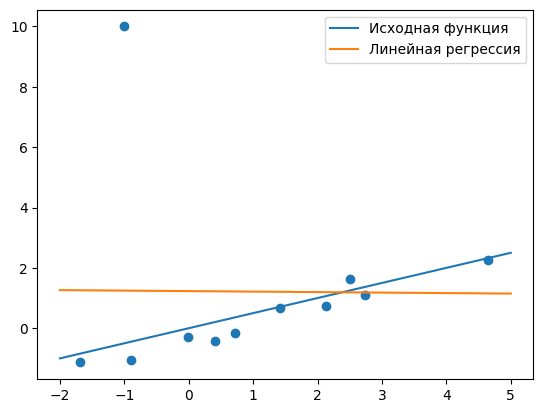

In [20]:
np.random.seed(51)

b = 0.5
# генерируем выборку
x_min, x_max = -2, 5
x = np.random.uniform(x_min, x_max, 10)
center = x * b + np.random.normal(0, 0.5, 10)
# добавляем аномальную точку
x = np.append(x, -1)
center = np.append(center, 10)

model = LinearRegression()
model.fit(x[:,None],center)
t = np.linspace(x_min, x_max, 200)
# рисование
plt.scatter(x, center)
plt.plot(t, b * t, label="Исходная функция")
plt.plot(t, model.predict(t[:,None]), label="Линейная регрессия")
plt.legend()

Как мы видим, всего одна точка очень сильно изменила получаемую функцию. Мы бы хотели научиться игнорировать такие аномальные точки.

## RANSAC регрессия

RANSAC Расшифровывается как RANdom SAmple Consensus, в переводе "случайный консенсус выборки". Идея метода состоит в том, что точки данных делятся на два вида: нормальные и выбросы. Задача сводится к тому, чтобы отличить одни от других. Реализуется это следующим алгоритмом:
1. Выбрать случайное подмножество входных данных;
2. Обучить на них модель;
3. Посмотреть, насколько хорошо модель подходит имеющимся данным; подмножество точек, которые подходят «хорошо» (что бы это ни значило), называется консенсусным множеством (consensus set) для текущей модели;
4. Если консенсусное множество S слишком маленькое (опять же что бы это ни значило), значит, нам не повезло с моделью и лучше вернуться к перво му шагу;
5. А если достаточно большое, то можно подсчитать, насколько хорошо модель подходит точкам из S, и если ошибка оказалась меньше, чем на предыдущих попытках, то сохранить модель как лучшую и тогда уже перезапускать процесс.

Изначально алгоритм кажется не очень сложным, но множество неточностей, требующих формализации, всё усложняет. К счастью, в sci-kit learn есть реализация этого метода. Тем не менее на нас всё ещё ложится ответственность за выбор параметров, отвечающих за размер подмножества, отвечающих за принятие или непринятие точек данных, отвечающих за размер консенсусного множества, отвечающих за количество итераций и т.д.

Мы же пока понадеемся на установленные параметры по умолчанию.

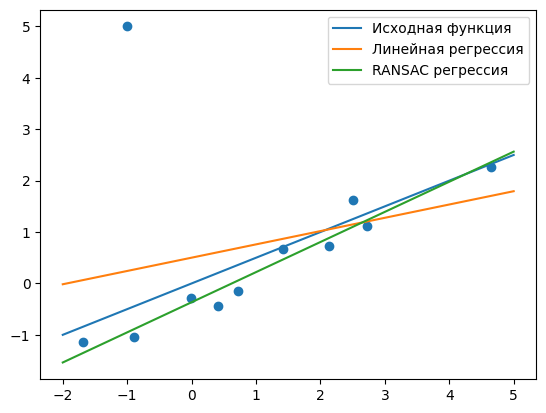

In [21]:
np.random.seed(51)

b = 0.5
# генерируем выборку
x_min, x_max = -2, 5
x = np.random.uniform(x_min, x_max, 10)
center = x * b + np.random.normal(0, 0.5, 10)
# добавляем аномальную точку
x = np.append(x, -1)
center = np.append(center, 5)

model = LinearRegression()
model.fit(x[:,None],center)
ransac = RANSACRegressor()
ransac.fit(x[:,None],center)
t = np.linspace(x_min, x_max, 200)
# рисование
plt.scatter(x, center)
plt.plot(t, b * t, label="Исходная функция")
plt.plot(t, model.predict(t[:,None]), label="Линейная регрессия")
plt.plot(t, ransac.predict(t[:,None]), label="RANSAC регрессия")
plt.legend()

Как мы видим, этот единичный выброс не влияет на RANSAC регрессию.

Но на самом деле, RANSAC регрессия устойчива и к большему количеству выбросов.

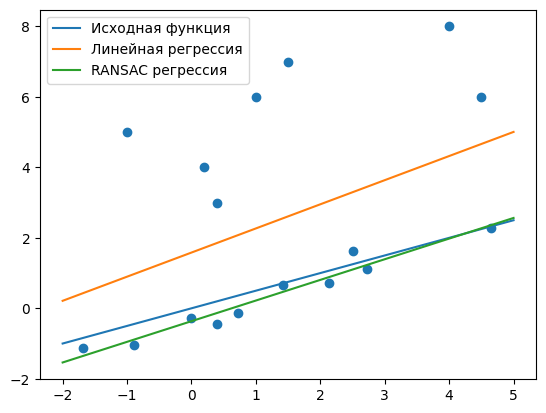

In [22]:
np.random.seed(51)

b = 0.5
# генерируем выборку
x_min, x_max = -2, 5
x = np.random.uniform(x_min, x_max, 10)
center = x * b + np.random.normal(0, 0.5, 10)
# добавляем аномальную точку
x = np.append(x, [-1, 0.2, 0.4, 1, 1.5, 4, 4.5])
center = np.append(center, [ 5,   4,   3, 6,   7, 8,   6])

model = LinearRegression()
model.fit(x[:,None], center)
ransac = RANSACRegressor()
ransac.fit(x[:,None], center)
t = np.linspace(x_min, x_max, 200)
# рисование
plt.scatter(x, center)
plt.plot(t, b * t, label="Исходная функция")
plt.plot(t, model.predict(t[:,None]), label="Линейная регрессия")
plt.plot(t, ransac.predict(t[:,None]), label="RANSAC регрессия")
plt.legend()

## Регрессия Тейла-сена

Этот метод регрессии основан на самой устойчивой оценке - на оценке параметров с использованием медианы.

Для этого через каждую пару точек проводятся прямые, коэффициент наклона прямой находится как медиана наклонов всех проведённых прямых. Свободный член также определяется как медиана остатков от вычитания $mx_i$:

$$m=Median_{i\neq j}\left(\frac{y_i-y_j}{x_i-x_j}\right), b=Median(y_i-mx_i).$$

Стоит отметить квадратичную $o(n^2)$ трудоёмкость данного алгоритма, требующую перебора всех пар точек.

Реализация этого метода также есть в sci-kit learn.

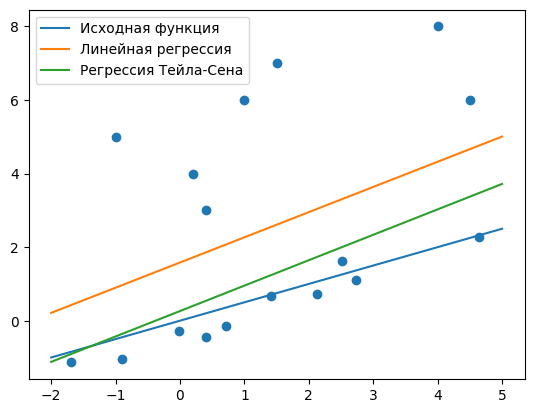

In [23]:
np.random.seed(51)

b = 0.5
# генерируем выборку
x_min, x_max = -2, 5
x = np.random.uniform(x_min, x_max, 10)
center = x * b + np.random.normal(0, 0.5, 10)
# добавляем аномальную точку
x = np.append(x, [-1, 0.2, 0.4, 1, 1.5, 4, 4.5])
center = np.append(center, [ 5,   4,   3, 6,   7, 8,   6])

model = LinearRegression()
model.fit(x[:,None], center)
theilsen = TheilSenRegressor()
theilsen.fit(x[:,None], center)
t = np.linspace(x_min, x_max, 200)
# рисование
plt.scatter(x, center)
plt.plot(t, b * t, label="Исходная функция")
plt.plot(t, model.predict(t[:,None]), label="Линейная регрессия")
plt.plot(t, theilsen.predict(t[:,None]), label="Регрессия Тейла-Сена")
plt.legend()

А теперь попробуем обе регрессии в многомерном случае (на примере локальных признаков).

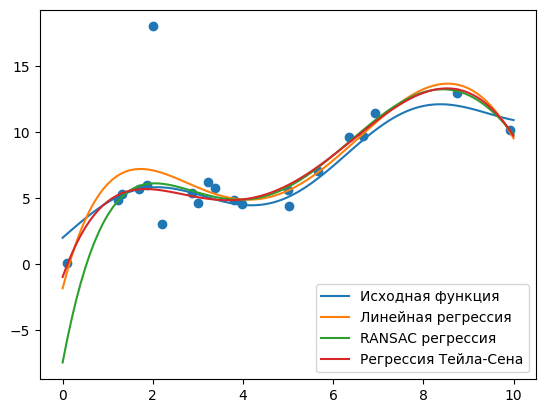

In [9]:
np.random.seed(60)
# Реальная зависимость в данных
relation = lambda x: 2 + x + 2 * np.sin(x) # использование numpy-функций позволяет использовать операции с массивами
# генерируем выборку
num_samples = 20    # Размер выборки
sigma = 1          # Дисперсия шума
x_min, x_max = 0, 10
x, center = generate_samples(relation, num_samples, x_min, x_max, sigma)
x = np.append(x, [2])
center = np.append(center, [18])

regression = make_pipeline(PolynomialFeatures(5), LinearRegression())
ransac = make_pipeline(PolynomialFeatures(5), RANSACRegressor())
theilsen = make_pipeline(PolynomialFeatures(5), RANSACRegressor())

regression.fit(x[:,None], center)
ransac.fit(x[:,None], center)
theilsen.fit(x[:,None], center)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, center)
plt.plot(t, relation(t), label="Исходная функция")

plt.plot(t, regression.predict(t[:, None]), label="Линейная регрессия")
plt.plot(t, ransac.predict(t[:, None]), label="RANSAC регрессия")
plt.plot(t, theilsen.predict(t[:, None]), label="Регрессия Тейла-Сена")
plt.legend()

А теперь попробуем применить локальные признаки на том же самом примере.

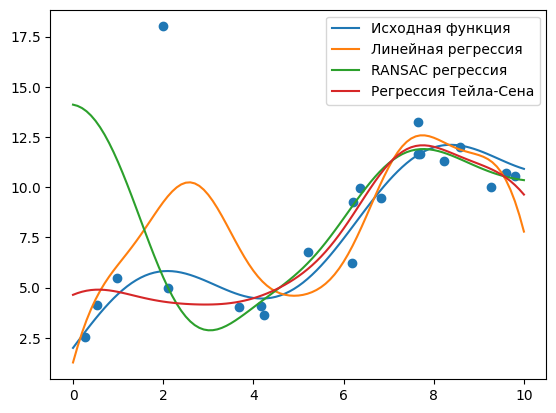

In [25]:
regression = make_pipeline(GaussianFeatures(5), LinearRegression())
ransac = make_pipeline(GaussianFeatures(5), RANSACRegressor())
theilsen = make_pipeline(GaussianFeatures(5), RANSACRegressor())

regression.fit(x[:,None], center)
ransac.fit(x[:,None], center)
theilsen.fit(x[:,None], center)

t = np.linspace(x_min, x_max, 101)

plt.scatter(x, center)
plt.plot(t, relation(t), label="Исходная функция")

plt.plot(t, regression.predict(t[:, None]), label="Линейная регрессия")
plt.plot(t, ransac.predict(t[:, None]), label="RANSAC регрессия")
plt.plot(t, theilsen.predict(t[:, None]), label="Регрессия Тейла-Сена")
plt.legend()

# Коэффициент детерминации

На предыдущей паре мы разговаривали про оценку моделей регрессии. Был предложен вариант, основанный на вычислении функции ошибки на обучающей и тестовой выборках. На основании разницы ошибок мы делали вывод о силе переобучения модели. 

Но такой подход имеет явный недостаток: Размер ошибки напрямую зависит от масштаба целевой переменной, поэтому величина функции ошибки совсем ничего не говорит о самом обучения. 

Предположим, мы обучили модель, протестировали её и получили значение MSE=100. Плохо это или хорошо? Если мы предсказываем цену автомобиля, то это хорошо, а если температуру воздуха на улице, то уже не очень хорошо.

А хотелось бы иметь простую метрику с фиксированной шкалой, которая не меняла бы своего смысла от задачи к задаче.

Для этого вводится **коэффициент детерминации**:

$$R^2=1-\frac{SS_{res}}{SS_{tot}}$$

где:
- $SS_{res}=\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2$ $-$ сумма квадратов остатков регрессии, соответствует ошибке, которую делает модель, то есть это дисперсия ответов модели. 
- $SS_{tot}=\frac{1}{n}\sum_{i=1}^{n}(y-\overline{y})^2$ $-$ общая сумма квадратов, это дисперсия целевой переменной.

$\hat{y}_i$ $-$ предсказание модели, $y_i$ $-$ настоящее значение, $\overline{y}=\frac{1}{n}\sum_{i=1}^ny_i$ $-$ среднее значение.

Коэффициент детерминации отражает то, какую часть дисперсии данных модель смогла объяснить. Чем значение ближе к единице, тем лучше. Принимать он может значения от $-\infty$ до $1$. Отрицательные значения можно получить на тестовой выборке, если модель сильно переобучена, обычно же если модель делает хоть сколько-то релевантный ответ, то коэффициент детерминации будет положителен.


<!-- При применении модели линейной регрессии выполняется равенство $SS_{reg}+SS_{res}=SS_{tot}$, $SS_{reg}=\sum_{i=1}^{n}(\hat{y}_i-\overline{y})^2$ $-$ дисперсия ответов модели. Поэтому формула может быть упрощена: -->

<!-- $$R^2=\frac{SS_{reg}}{SS_{tot}}.$$ -->



В scikit-learn есть возможность вычислить коэффициент детерминации вызвав метод `score` у модели.

d:\envs\main\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.54182e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
d:\envs\main\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.052e+01, tolerance: 1.870e-02
  model = cd_fast.enet_coordinate_descent(


,name,train r2,test r2
0,OLS,0.930019,-0.428262
1,Ridge,0.926565,0.869857
2,Lasso,0.891820,0.869441


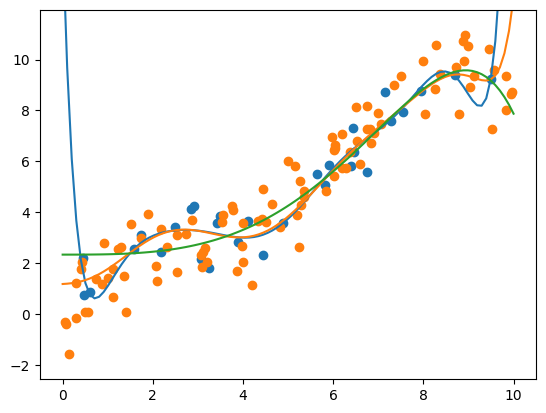

In [26]:
fun = lambda x: x + np.sin(x)
np.random.seed(51)
x_train, y_train = generate_samples(fun, 30, 0, 10, 1)
x_test, y_test = generate_samples(fun, 100, 0, 10, 1)
plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)

t = np.linspace(0,10,100)

models = [("OLS", LinearRegression()),
          ("Ridge", Ridge(alpha=1)),
          ("Lasso", Lasso(alpha=1)),
            ]
rez = []
for name,model in models:
    pipe = make_pipeline(PolynomialFeatures(degree=10), model)
    pipe.fit(x_train.reshape(-1, 1), y_train)
    
    rez.append({"name": name, 
                "train r2": pipe.score(x_train.reshape(-1,1), y_train),
                "test r2": pipe.score(x_test.reshape(-1,1), y_test),
                })
    plt.plot(t,pipe.predict(t.reshape(-1,1)))    
plt.ylim(y_test.min()-1, y_test.max()+1)

pd.DataFrame(rez)

Для регрессии без регуляризации коэффициент детерминации получился отрицательным из-за слишком большой ошибки на концах по причине резкого возрастания функции.

Если дисперсия шума, наложенного на данные, слишком большая, то мы получим низкий коэффициент детерминации потому что модель не способна описать этот шум.

d:\envs\main\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.54182e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
d:\envs\main\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.174e+02, tolerance: 3.535e-02
  model = cd_fast.enet_coordinate_descent(


,name,train r2,test r2
0,OLS,0.407525,-7.887586
1,Ridge,0.366954,0.390094
2,Lasso,0.335885,0.383925


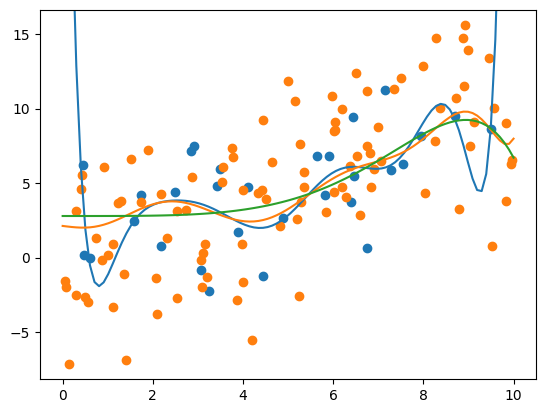

In [27]:
fun = lambda x: x + np.sin(x)
np.random.seed(51)
x_train, y_train = generate_samples(fun, 30, 0, 10, 4)
x_test, y_test = generate_samples(fun, 100, 0, 10, 4)
plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)

t = np.linspace(0,10,100)

models = [("OLS", LinearRegression()),
          ("Ridge", Ridge(alpha=1)),
          ("Lasso", Lasso(alpha=1)),
            ]
rez = []
for name,model in models:
    pipe = make_pipeline(PolynomialFeatures(degree=10), model)
    pipe.fit(x_train.reshape(-1, 1), y_train)
    
    rez.append({"name": name, 
                "train r2": pipe.score(x_train.reshape(-1,1), y_train),
                "test r2": pipe.score(x_test.reshape(-1,1), y_test),
                })
    plt.plot(t,pipe.predict(t.reshape(-1,1)))    
plt.ylim(y_test.min()-1, y_test.max()+1)

pd.DataFrame(rez)

# Домашнее задание

- Сгенерируйте выборку со сложной зависимостью. Обучите регрессию с локальными базисными признаками. Поэкспериментируйте с параметром ширины гауссиан. Какое значение оптимально? Объясните своё решение.
- Сгенерируйте выборку с простой линейной зависимостью. Добавьте в выборку выбросы (к примеру, для случайных точек замените $y$ на аномально большое значение). Обучите обычную и робастную линейную регрессию, выведите коэффициент детерминации и суммарную функции ошибки. Объясните полученные результаты.
- Для построенных моделей постройте распределение значений функции ошибки. Чем отличаются графики?